# Stock Price Prediction using HMM, LSTM, ARIMA, and RNN

In this notebook, we will predict stock prices using various methods including Hidden Markov Model (HMM), Long Short-Term Memory (LSTM), AutoRegressive Integrated Moving Average (ARIMA), and Recurrent Neural Network (RNN). We will compare the performance of these models using various error metrics.


In [1]:
# Import necessary libraries for data manipulation, model building, and evaluation

from hmmlearn import hmm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm

from evaluationFuncs import ape, aae, arpe, rmse, direction_accuracy

from modelFuncs import dataExtracterMonths, dataExtracterDays, HMMPricePredictor

## Load and Prepare Data

In this section, we load the data and preprocess it for modeling.


In [2]:
df_nvo = dataExtracterDays('NVO', '2016-01-01', '2026-01-01')
df_nvo['Return'] = df_nvo['Close'].pct_change()
df_nvo =df_nvo.dropna()

[*********************100%***********************]  1 of 1 completed

The dataset has observations across 2514 days


## Hidden Markov Model (HMM)

We will implement the HMM to predict future stock prices.

In [145]:
def HMM_predictBroadcast(obsData, train_size, window_size, Ncomp):
    obs = obsData.copy()
    train = obs[:train_size]
    train_data = train['Return'].values.reshape(-1, 1)
    
    # Train global HMM
    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_data)
    
    means = model.means_
    
    print(means*100)
    print(np.round(model.transmat_, 2))
    
    
    T = max(window_size, train_size)
    predictions = []
    returns = []
    doprint = True
    while T < len(obs):
        window = obs[['Return']].iloc[T-window_size:T]

        # Probability distribution of hidden states for current step
        state_probs = model.predict_proba(window)[-1]

        # Expected distribution of hidden states for next step
        next_state_probs = state_probs @ model.transmat_

        # Expected return across all states
        predicted_return = np.dot(next_state_probs, means)
        
        if doprint:
            print(f"State probabilities: {np.round(state_probs, 2)}")
            print(f"Next state probabilities: {np.round(next_state_probs, 2)}")
            print(f"Expected return: {predicted_return}")
            doprint = False

        # Convert to price
        predicted_price = obs['Close'].iloc[T-1] * (1 + predicted_return)

        returns.append(predicted_return[0])
        predictions.append(predicted_price)
        T += 1

    close = obs['Close'].iloc[train_size:].values

    return predictions, close, returns

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


In [79]:
df_nvoV2 = df_nvo.copy()
df_nvoV2['Volatility'] = df_nvoV2['Return'].rolling(10).std()
df_nvoV2['Momentum'] = df_nvoV2['Close'].pct_change(5)
df_nvoV2 = df_nvoV2.dropna()

In [80]:
df_nvoV2

,Date,Open,High,Low,Close,Return,Volatility,Momentum
10,2016-01-19,21.714837,21.755289,21.391219,21.520666,0.001506,0.018116,-0.024391
11,2016-01-20,21.172780,21.565168,20.857252,21.395267,-0.005827,0.016862,-0.045824
12,2016-01-21,21.613716,21.735072,21.346730,21.569218,0.008130,0.017653,-0.014964
13,2016-01-22,21.917101,22.248810,21.900920,22.143635,0.026631,0.019691,-0.004003
14,2016-01-25,22.289267,22.588615,22.204317,22.353991,0.009500,0.018519,0.040286
...,...,...,...,...,...,...,...,...
2509,2025-12-24,52.849998,53.630001,52.000000,52.560001,0.018407,0.028437,0.100272
2510,2025-12-26,53.020000,53.029999,51.700001,52.400002,-0.003044,0.027850,0.100609
2511,2025-12-29,51.560001,51.990002,51.349998,51.470001,-0.017748,0.028685,0.070285
2512,2025-12-30,51.520000,51.669998,51.070000,51.220001,-0.004857,0.028786,0.064865


In [103]:
def HMM_predictV2_feat(obsData, train_size, window_size, Ncomp):
    obs = obsData.copy()
    train = obs[:train_size]
    features = ['Return', 'Volatility', 'Momentum']
    train_data = train[features].values
    print(np.sum(np.isnan(train_data)))
    train_scaled = scaler.fit_transform(train_data)
    # Train global HMM
    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_scaled)
    
    means = model.means_
    stds = np.sqrt(model._covars_)
    print("State-wise means:", np.round(means.flatten(), 3))
    print("State-wise std:", stds.flatten())
    print("State counts:", np.bincount(model.predict(train_scaled)))


    print(np.round(model.transmat_, 2))
    
    first = True
    T = max(window_size, train_size)
    predictions = []
    returns = []
    while T < len(obs):
        window = obs[features].iloc[T-window_size:T]

        # Probability distribution of hidden states for current step
        current_state = model.predict(window)[-1]

        # Expected distribution of hidden states for next step
        next_state = np.random.choice(len(means), p=model.transmat_[current_state])

        # Expected return across all states
        predicted_return_scaled = norm.rvs(loc=means[next_state][0], scale=stds[next_state][0])

        dummy = np.zeros((1, len(features)))
        dummy[0, 0] = predicted_return_scaled

        predicted_return = scaler.inverse_transform(dummy)[0, 0]
        

        # Convert to price
        predicted_price = obs['Close'].iloc[T-1] * (1 + predicted_return)
        if first:
            print(f"Date for day before first prediction: {obs['Date'].iloc[T-1]}")
            print(f"Date for first day of real data: {obs['Date'].iloc[train_size]}")
            first = False

        returns.append(predicted_return)
        predictions.append(predicted_price)
        T += 1

    close = obs['Close'].iloc[train_size:].values

    return predictions, close, returns

In [149]:
def HMM_predict_sample(obsData, train_size, window_size, Ncomp):
    obs = obsData.copy()
    train = obs[:train_size]
    train_data = train['Return'].values.reshape(-1, 1)
    train_scaled = scaler.fit_transform(train_data)
    # Train global HMM
    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_scaled)
    
    means = model.means_
    stds = np.sqrt(model._covars_)
    print("The means are:", np.round(means.flatten(), 3))
    print("The standard deviations are:", np.round(stds.flatten(), 2))


    print(np.round(model.transmat_, 2))
    
    first = True
    T = max(window_size, train_size)
    predictions = []
    returns = []
    while T < len(obs):
        window = obs[['Return']].iloc[T-window_size:T]

        # Probability distribution of hidden states for current step
        current_state = model.predict(window)[-1]

        # Expected distribution of hidden states for next step
        next_state = np.random.choice(len(means), p=model.transmat_[current_state])

        # Expected return across all states
        predicted_return = scaler.inverse_transform(norm.rvs(loc=means[next_state], scale=stds[next_state], size=1).reshape(-1,1))[0]
        

        # Convert to price
        predicted_price = obs['Close'].iloc[T-1] * (1 + predicted_return)
        if first:
            print(f"Date for day before first prediction: {obs['Date'].iloc[T-1]}")
            print(f"Date for first day of real data: {obs['Date'].iloc[train_size]}")
            first = False

        returns.append(predicted_return)
        predictions.append(predicted_price)
        T += 1

    close = obs['Close'].iloc[train_size:].values

    return predictions, close, returns

In [131]:
def HMM_predictV2_log(obsData, train_size, window_size, Ncomp):
    obs = obsData.copy()
    obs['LogReturn'] = np.log(1 + obs['Return'])
    train = obs[:train_size]
    train_data = train['LogReturn'].values.reshape(-1, 1)
    train_scaled = scaler.fit_transform(train_data)
    # Train global HMM
    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_scaled)
    
    means = model.means_
    stds = np.sqrt(model._covars_)
    print("The means are:", np.round(means.flatten(), 3))
    print("The standard deviations are:", np.round(stds.flatten(), 2))


    print(np.round(model.transmat_, 2))
    
    first = True
    T = max(window_size, train_size)
    predictions = []
    returns = []
    while T < len(obs):
        window = obs[['LogReturn']].iloc[T-window_size:T]

        # Probability distribution of hidden states for current step
        current_state = model.predict(window)[-1]

        # Expected distribution of hidden states for next step
        next_state = np.random.choice(len(means), p=model.transmat_[current_state])

        # Expected return across all states
        predicted_log_return = scaler.inverse_transform(norm.rvs(loc=means[next_state], scale=stds[next_state], size=1).reshape(-1,1))[0]
        

        # Convert to price
        last_price = obs['Close'].iloc[T-1]
        predicted_price = last_price * np.exp(predicted_log_return)
        if first:
            print(f"Date for day before first prediction: {obs['Date'].iloc[T-1]}")
            print(f"Date for first day of real data: {obs['Date'].iloc[train_size]}")
            first = False

        returns.append(predicted_log_return)
        predictions.append(predicted_price)
        T += 1

    close = obs['Close'].iloc[train_size:].values

    return predictions, close, returns

In [150]:
Ntrain = 300
Nwindow = 50
NStates = 8

NVO_predictions, real, predReturns = HMM_predict_sample(df_nvo, train_size=Ntrain, window_size=Nwindow, Ncomp=NStates)
NVO_predictions_feat, real_feat, predReturns_feat = HMM_predictV2_feat(df_nvoV2, train_size=Ntrain, window_size=Nwindow, Ncomp=NStates)
NVO_predictions_log, real_log, predReturns_log = HMM_predictV2_log(df_nvo, train_size=Ntrain, window_size=Nwindow, Ncomp=NStates)
NVO_predictions_broadcast, real_broadcast, predReturns_broadcast = HMM_predictBroadcast(df_nvo, train_size=Ntrain, window_size=Nwindow, Ncomp=NStates)

The means are: [-0.048 -2.579  0.89  -4.381  0.12   4.393 -0.809 -0.211]
The standard deviations are: [0.58 0.52 0.63 1.97 0.58 0.1  0.83 1.67]
[[0.   0.02 0.19 0.03 0.76 0.01 0.   0.  ]
 [0.01 0.1  0.   0.   0.   0.   0.63 0.26]
 [0.   0.   0.   0.   0.74 0.   0.06 0.2 ]
 [0.   0.   0.1  0.   0.   0.   0.01 0.89]
 [0.99 0.   0.   0.01 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   1.   0.   0.   0.  ]
 [0.01 0.   0.27 0.   0.04 0.   0.62 0.07]
 [0.02 0.   0.   0.   0.92 0.   0.06 0.  ]]
Date for day before first prediction: 2017-03-14
Date for first day of real data: 2017-03-15
0
State-wise means: [ 0.093 -0.566  0.182 -0.527  2.635 -2.039  0.156  1.314 -1.673 -0.452
  1.306 -1.918  0.044 -0.57   0.166 -3.928  1.291 -2.15   0.416  0.898
  0.668  0.162  0.748  0.4  ]
State-wise std: [0.64749972 0.28515634 0.59895562 0.21676285 0.41321224 1.11557143
 0.86502241 1.12295457 0.80914602 1.16666997 1.18349962 1.00795218
 0.60216865 0.29529721 0.58336531 1.71296484 1.05720227 0.85596836
 1.102373

## Plot Predictions

Now, we plot the predictions from all models alongside the actual observed prices.


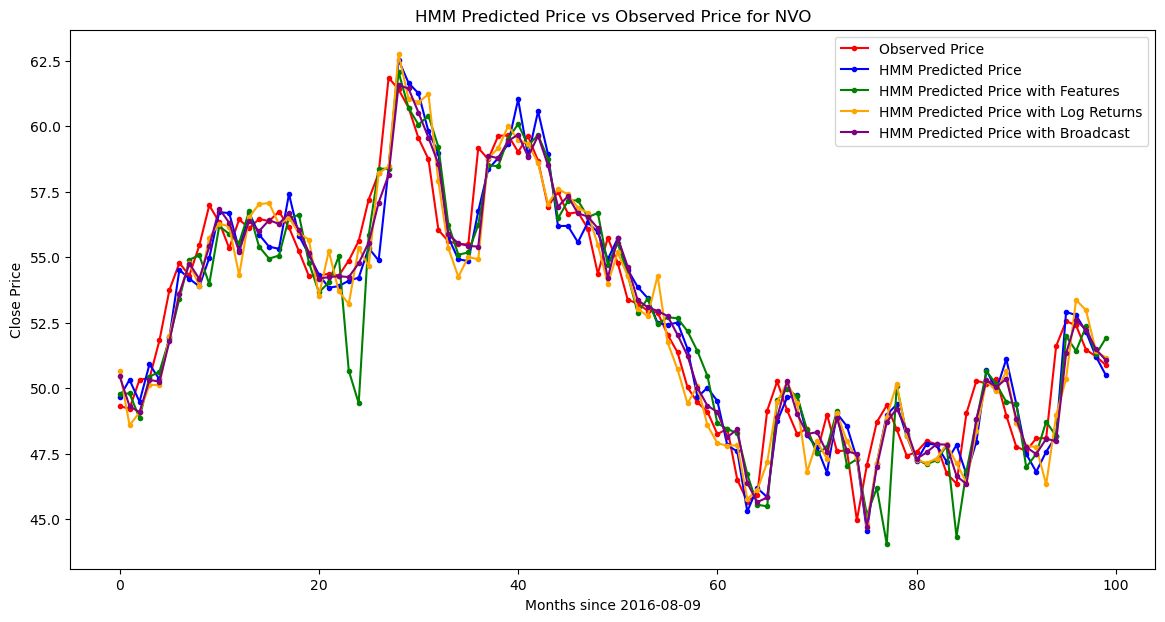

In [147]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot actual prices for the corresponding period
ax.plot(real[-100:], marker='.', label='Observed Price', color='red')
ax.plot(NVO_predictions[-100:], marker='.', label='HMM Predicted Price', color='blue')
ax.plot(NVO_predictions_feat[-100:], marker='.', label='HMM Predicted Price with Features', color='green')
ax.plot(NVO_predictions_log[-100:], marker='.', label='HMM Predicted Price with Log Returns', color='orange')
ax.plot(NVO_predictions_broadcast[-100:], marker='.', label='HMM Predicted Price with Broadcast', color='purple')
ax.set_ylabel("Close Price")
ax.set_xlabel(f"Months since {df_nvo['Date'].iloc[150]}")
ax.legend();
ax.set_title(f"HMM Predicted Price vs Observed Price for NVO");

## Model evaluation

Finally, we will evaluate the performance of each model using metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Direction Accuracy.

In [148]:
# Convert lists to numpy arrays
realPrices = [real, real_feat, real_log, real_broadcast]
predictions = [NVO_predictions, NVO_predictions_feat, NVO_predictions_log, NVO_predictions_broadcast]

for i, (close, hmm_price) in enumerate(zip(realPrices, predictions)):
    ape_hmm = ape(close, hmm_price)
    aae_hmm = aae(close, hmm_price)
    arpe_hmm = arpe(close, hmm_price)
    rmse_hmm = rmse(close, hmm_price)
    direction_accuracy_hmm = direction_accuracy(close, hmm_price)
    print(f"Absolute Percentage Error for HMM {i+1}: ", ape_hmm)
    print(f"Average Absolute Error for HMM {i+1}: ", aae_hmm)
    print(f"Average Relative Percentage Error for HMM {i+1}: ", arpe_hmm)
    print(f"Root Mean Squared Error for HMM {i+1}: ", rmse_hmm)
    print(f"Direction Accuracy for HMM {i+1}: ", direction_accuracy_hmm, "\n")

Absolute Percentage Error for HMM 1:  0.017559030453981224
Average Absolute Error for HMM 1:  0.8901729168233026
Average Relative Percentage Error for HMM 1:  0.00040224713819399124
Root Mean Squared Error for HMM 1:  1.5264981764035679
Direction Accuracy for HMM 1:  0.49819168173598555 

Absolute Percentage Error for HMM 2:  0.020573214332738506
Average Absolute Error for HMM 2:  1.0460490470780184
Average Relative Percentage Error for HMM 2:  0.00047461390520781233
Root Mean Squared Error for HMM 2:  1.8294976746962137
Direction Accuracy for HMM 2:  0.4929641398093509 

Absolute Percentage Error for HMM 3:  0.019006690750899634
Average Absolute Error for HMM 3:  0.9635635287055756
Average Relative Percentage Error for HMM 3:  0.00043541054166542053
Root Mean Squared Error for HMM 3:  1.6571058835952877
Direction Accuracy for HMM 3:  0.49683544303797467 

Absolute Percentage Error for HMM 4:  0.014624009241416927
Average Absolute Error for HMM 4:  0.7413790297932675
Average Relative P

# Bonus

In [ ]:
def HMM_predictV2(obsData, train_size, window_size, Ncomp):
    obs = obsData.copy()
    train = obs[:train_size]
    train_data = train['Return'].values.reshape(-1, 1)
    # Train global HMM
    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_data)
    
    means = model.means_
    stds = np.sqrt(model._covars_)
    print("The means are:", np.round(means.flatten(), 3))
    print("The standard deviations are:", np.round(stds.flatten(), 2))


    print(np.round(model.transmat_, 2))
    
    first = True
    T = max(window_size, train_size)
    predictions = []
    returns = []
    while T < len(obs):
        window = obs[['Return']].iloc[T-window_size:T]

        # Probability distribution of hidden states for current step
        current_state = model.predict(window)[-1]

        # Expected distribution of hidden states for next step
        next_state = np.random.choice(len(means), p=model.transmat_[current_state])

        # Expected return across all states
        predicted_return = norm.rvs(loc=means[next_state], scale=stds[next_state], size=1, random_state=123)
        

        # Convert to price
        predicted_price = obs['Close'].iloc[T-1] * (1 + predicted_return)
        if first:
            print(f"Date for day before first prediction: {obs['Date'].iloc[T-1]}")
            print(f"Date for first day of real data: {obs['Date'].iloc[train_size]}")
            first = False

        returns.append(predicted_return[0])
        predictions.append(predicted_price)
        T += 1

    close = obs['Close'].iloc[train_size:].values

    return predictions, close, returns